# Creating synthetic data

In [27]:
import torch
import torch.nn as nn
from torch import optim
import matplotlib.pyplot as plt

X = torch.arange(-30, 30, 1).view(-1, 1).float()
Y = torch.zeros(X.shape[0])

# Assign label 1.0 to elements in Y where the corresponding X value is less than or equal to -10
Y[X[:, 0] <= -10] = 1.0

# Assign label 0.5 to elements in Y where the corresponding X value falls between -10 and 10 (exclusive)
Y[(X[:, 0] > -10) & (X[:, 0] < 10)] = 0.5

# Assign label 0 to elements in Y where the corresponding X value is greater than 10
Y[X[:, 0] > 10] = 0

## Plotting the data

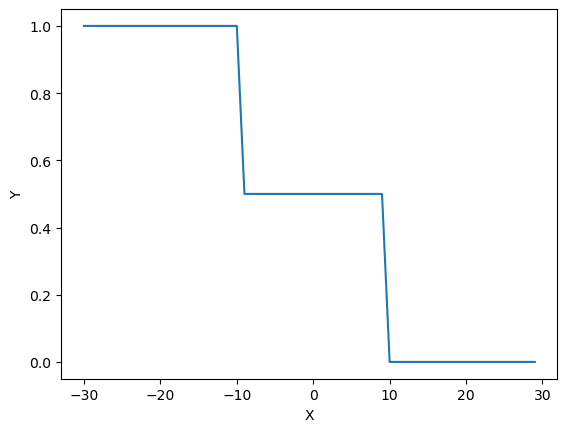

In [28]:
import matplotlib.pyplot as plt

# Create a plot of X against Y
plt.plot(X, Y)

# Add X and Y labels to the plot
plt.xlabel('X')
plt.ylabel('Y')

# Display the plot
plt.show()

# Defining the Perceptron class

## Type 1

In [29]:
class SingleLayerPerceptron:
    def __init__(self, input_size):
        # Initialize weights and bias
        self.weights = torch.randn(input_size)
        self.bias = torch.randn(1)

    def activation_function(self, x):
        # Step function as the activation function
        return 1.0 if x >= 0 else 0.0

    def predict(self, x):
        # Calculate the linear combination of inputs and weights
        linear_output = torch.dot(self.weights, x) + self.bias
        # Apply the activation function to get the predicted label
        predicted_label = self.activation_function(linear_output)
        return predicted_label

    def train(self, X, Y, learning_rate=0.01, epochs=100):
        for epoch in range(epochs):
            for i in range(X.shape[0]):
                # Get the current input and label
                x = X[i]
                y = Y[i]

                # Make a prediction
                predicted = self.predict(x)

                # Update weights and bias based on the error
                error = y - predicted
                self.weights += learning_rate * error * x
                self.bias += learning_rate * error

## Type 2:

In [30]:
class SingleLayerNet(nn.Module):
    def __init__(self, input_size, hidden_neurons, output_size):
        super(SingleLayerNet, self).__init__()
        # Define the hidden layer with input_size input features and hidden_neurons neurons
        self.hidden_layer = nn.Linear(input_size, hidden_neurons)

        # Define the output layer with hidden_neurons input features and output_size neurons
        self.output_layer = nn.Linear(hidden_neurons, output_size)
        
        # Initialize weights using Xavier initialization for better convergence
        nn.init.xavier_uniform_(self.hidden_layer.weight)
        nn.init.xavier_uniform_(self.output_layer.weight)
        nn.init.zeros_(self.hidden_layer.bias)
        nn.init.zeros_(self.output_layer.bias)
        
    def forward(self, x):
        # Pass the input through the hidden layer and apply the sigmoid activation function
        hidden_output = torch.sigmoid(self.hidden_layer(x))

        # Pass the hidden layer output through the output layer and apply the sigmoid activation function
        y_pred = torch.sigmoid(self.output_layer(hidden_output))

        return y_pred

In [31]:
# Instantiate
# 2 represents two neurons in one hidden layer
perceptron = SingleLayerNet(1,2,1)
perceptron

SingleLayerNet(
  (hidden_layer): Linear(in_features=1, out_features=2, bias=True)
  (output_layer): Linear(in_features=2, out_features=1, bias=True)
)

# Training the Model

In [32]:
# Define the loss function using PyTorch's built-in BCELoss (more numerically stable)
criterion = nn.BCELoss()  # Binary Cross Entropy Loss with better numerical stability

In [33]:
# Create an optimizer (Stochastic Gradient Descent - SGD) with optimized learning rate
optimizer = optim.SGD(perceptron.parameters(), lr=0.1)

# Optional: Add learning rate scheduler for adaptive learning rate decay
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.9)

## The Training Loop

In [34]:
epochs = 5000
cost = []  # List to store the cost values for each epoch
train_losses = []
val_losses = []

# Reshape Y to match model output shape (N, 1)
Y_reshaped = Y.view(-1, 1)

# Split data into training and validation sets (90/10 split)
split_idx = int(0.9 * len(X))
X_train, X_val = X[:split_idx], X[split_idx:]
Y_train, Y_val = Y_reshaped[:split_idx], Y_reshaped[split_idx:]

for epoch in range(epochs):
    # === TRAINING PHASE ===
    # Zero out the gradients FIRST to avoid accumulation
    optimizer.zero_grad()

    # Forward pass: Compute predicted y by passing training data to the model
    y_pred_train = perceptron(X_train)

    # Calculate the loss between the predicted and true labels
    loss_train = criterion(y_pred_train, Y_train)

    # Backward pass: Compute gradients of the loss with respect to model parameters
    loss_train.backward()

    # Update the model parameters using the optimizer
    optimizer.step()

    # === VALIDATION PHASE ===
    with torch.no_grad():  # No gradient computation needed for validation
        y_pred_val = perceptron(X_val)
        loss_val = criterion(y_pred_val, Y_val)

    # Store losses
    train_losses.append(loss_train.item())
    val_losses.append(loss_val.item())
    cost.append(loss_train.item())  # Keep for backward compatibility

    # Step the learning rate scheduler
    scheduler.step()

    if (epoch + 1) % 1000 == 0:
        print(f"Epoch {epoch + 1:>4d} | Train Loss: {loss_train.item():.6f} | Val Loss: {loss_val.item():.6f}")

Epoch 1000 | Train Loss: 0.353085 | Val Loss: 0.078239
Epoch 2000 | Train Loss: 0.340124 | Val Loss: 0.050831
Epoch 3000 | Train Loss: 0.335480 | Val Loss: 0.041468
Epoch 4000 | Train Loss: 0.333017 | Val Loss: 0.036642
Epoch 5000 | Train Loss: 0.331471 | Val Loss: 0.033662


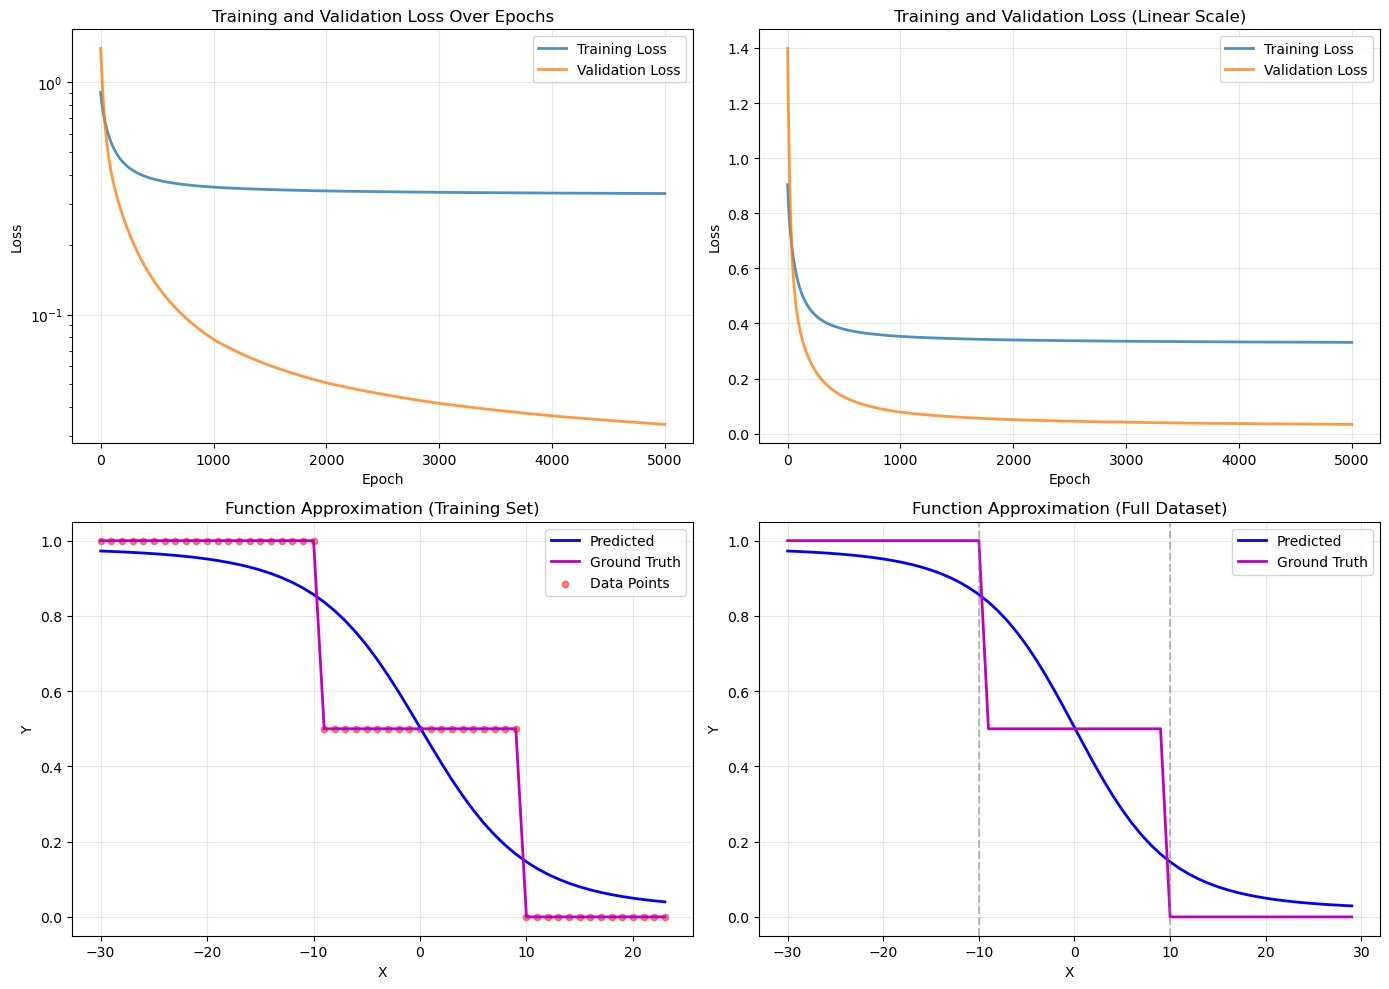

In [36]:
# Create a comprehensive visualization with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Training and Validation Loss Curves
axes[0, 0].plot(train_losses, label='Training Loss', linewidth=2, alpha=0.8)
axes[0, 0].plot(val_losses, label='Validation Loss', linewidth=2, alpha=0.8)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss Over Epochs')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_yscale('log')  # Log scale for better visualization of convergence

# Plot 2: Loss Curve (Linear Scale)
axes[0, 1].plot(train_losses, label='Training Loss', linewidth=2, alpha=0.8)
axes[0, 1].plot(val_losses, label='Validation Loss', linewidth=2, alpha=0.8)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Training and Validation Loss (Linear Scale)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Function Approximation - Training Data
predicted_values_train = perceptron(X_train).detach().numpy()
axes[1, 0].plot(X_train.numpy(), predicted_values_train, 'b-', linewidth=2, label='Predicted')
axes[1, 0].plot(X_train.numpy(), Y_train.numpy(), 'm-', linewidth=2, label='Ground Truth')
axes[1, 0].scatter(X_train.numpy(), Y_train.numpy(), color='red', s=20, alpha=0.5, label='Data Points')
axes[1, 0].set_xlabel('X')
axes[1, 0].set_ylabel('Y')
axes[1, 0].set_title('Function Approximation (Training Set)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Function Approximation - Full Dataset
predicted_values_full = perceptron(X).detach().numpy()
axes[1, 1].plot(X.numpy(), predicted_values_full, 'b-', linewidth=2, label='Predicted')
axes[1, 1].plot(X.numpy(), Y.numpy(), 'm-', linewidth=2, label='Ground Truth')
axes[1, 1].axvline(x=-10, color='gray', linestyle='--', alpha=0.5)  # Decision boundary
axes[1, 1].axvline(x=10, color='gray', linestyle='--', alpha=0.5)   # Decision boundary
axes[1, 1].set_xlabel('X')
axes[1, 1].set_ylabel('Y')
axes[1, 1].set_title('Function Approximation (Full Dataset)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
# Print final statistics
print(f"\n{'='*50}")
print(f"Final Training Loss: {train_losses[-1]:.6f}")
print(f"Final Validation Loss: {val_losses[-1]:.6f}")
print(f"Improvement: {((train_losses[0] - train_losses[-1]) / train_losses[0] * 100):.2f}%")
print(f"{'='*50}")


Final Training Loss: 0.331471
Final Validation Loss: 0.033662
Improvement: 63.31%
